# chrisMain — VarMeanNoise Analysis

Goal: pull stimulus + response data for the `varMeanNoise` protocol, then transfer cell types and STAs from the nearest noise (`SpatialNoise`) chunk via EI matching.

Steps:
1. Find every experiment that ran `varMeanNoise`
2. Pick a date
3. Build the pipeline (StimBlock + ResponseBlock for the protocol, AnalysisChunk for the noise chunk; `create_mea_pipeline` runs the EI-based cluster match automatically)
4. Sanity-check the matching by comparing RFs
5. Pull spike trains as an xarray for downstream analysis

---

### Workflow ordering (per experiment)

The §-numbers below tell the conceptual story (visual QC is a filter, so it sits *before* archives), but the **first-time execution order** is iterative:

1. **§14** — compute protocol QC → writes `qc.csv`.
2. **§17** (single date) or **§18** (batch) — render every QC-passing cell's PNGs + `cell_match.csv`.
3. **§16** — `ra.browse_cells_qc(exp_name)` to click through and tag → writes `visual_qc.csv`.
4. **§17 / §18 again** — `analyze_experiment` auto-detects `visual_qc.csv` and re-renders only the cells tagged `good`. Manual tags are read-only to archiving — re-runs never overwrite them.

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

## 1. Find all experiments that ran `varMeanNoise`

`get_datasets_from_protocol_names` does a lowercase substring match against the protocol registry, so `'varmeannoise'` will catch the full Java class name (e.g. `manookinlab.protocols.VarMeanNoise`). After the DB query we filter to only experiments whose sort output is actually present on disk (`ra.ANALYSIS_DIR`).

In [2]:
exp_search = ra.get_datasets_from_protocol_names('AlternatingBackground')

# Filter to experiments that exist on the MEA SSD
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop=True)

print(f'{len(exp_search)} usable datafile(s) found across '
      f'{exp_search.exp_name.nunique()} experiment(s).')
display(exp_search)


Found 1 protocols matching "alternatingbackground":
['edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']

Found 22 experiments, 31 epoch blocks.

26 usable datafile(s) found across 19 experiment(s).


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20230214C,data018,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230214C/data018,eye movement alt background ndf 3.0,39,41,781,1484,97
1,20230313C,data017,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data017,eye movement alt background ndf 3.0,42,41,878,1609,108
2,20230313C,data019,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data019,Var Mean Drift Grating ndf 3.0,42,41,879,1611,108
3,20230502C,data018,2.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230502C/data018,ndf 2.0 eye movement alt background,52,41,1077,1855,156
4,20230523C,data013,2.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230523C/data013,Eye movement alt background,56,41,1178,1983,176
5,20230525C,data052,0.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230525C/data052,Eye Movement Alternating Background Photopic,58,41,1220,2041,184
6,20230725C,data036,2.0,chunk4,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230725C/data036,ndf 2 eye movement alt background,65,41,1397,2264,205
7,20231003C,data021,0.5,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20231003C/data021,eye movement alt background,71,41,1516,2416,221
8,20231108C,data005,0.5,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20231108C/data005,eye movement alt background,74,41,1556,2462,243
9,20231220C,data022,0.5,chunk4,edu.washington.riekelab.turner.protocols.EyeMo...,1,20231220C/data022,CC eye movement alt background,76,41,1607,2517,252


## 2. Pick a (date, datafile)

`exp_search` (§1) has **one row per (exp_name, datafile_name) pair**, so multiple datafiles of the same protocol on one date are already separated into distinct rows. Just pick an index into that table — no need to write the date and the datafile separately and risk them drifting apart.

In [ ]:
ENTRY_INDEX = 14   # <-- EDIT ME: row index in exp_search above

_entry = exp_search.iloc[ENTRY_INDEX]
exp_name      = _entry['exp_name']
datafile_name = _entry['datafile_name']
print(f'Selected entry {ENTRY_INDEX}: {exp_name} / {datafile_name}')

# Summary of the chosen day, capped at SUMMARY_HEAD_N rows so long experiments
# don't blow up the notebook output. Increase the cap if you need to inspect
# more rows (or call ra.get_exp_summary(exp_name) directly to see all of them).
SUMMARY_HEAD_N = 10
_sum_df = ra.get_exp_summary(exp_name)
print(f'\nexperiment summary: {len(_sum_df)} datafiles total '
      f'(showing first {min(SUMMARY_HEAD_N, len(_sum_df))})')
display(_sum_df.head(SUMMARY_HEAD_N))


## 3. Build the pipeline

`create_mea_pipeline` does everything in one shot:
- **StimBlock** — loads stimulus params and frame timing for the protocol datafile.
- **ResponseBlock** — loads spike times from the kilosort output for that datafile.
- **Noise chunk** — by default auto-resolved to the chunk closest in time (see `stim.py:get_nearest_noise`). **Set `noise_chunk_name = 'chunkN'`** at the top of the cell below to override this with a specific noise chunk — useful when the auto-pick lands on a chunk that ran *after* the protocol, or when you want to use an earlier sort.
- **Typing file** — set `typing_file_name = 'kilosort*.classification.txt'` to pick a specific classification file when the chunk has more than one.
- **AnalysisChunk** — loads STAs, RF params, EIs, ISIs, timecourses, and the classification (cell type) file from the noise chunk.
- **EI-based cluster match** — `cluster_match()` is called internally to align the noise-chunk cell IDs to the protocol cell IDs by EI footprint correlation. After this, the protocol cells carry `noise_id` and `cell_type` columns.

In [ ]:
# Older experiments are often sorted with kilosort2 (not 2.5). Auto-detect:
exp_sort_dir = os.path.join(ra.DATA_DIR, exp_name, datafile_name)
available_ss = [d for d in os.listdir(exp_sort_dir) if d.startswith('kilosort')]
ss_version = 'kilosort2.5' if 'kilosort2.5' in available_ss else available_ss[0]

# ---- USER INPUT --------------------------------------------------------
# Noise chunk to use for cell typing + EI matching.
#   None  → MEAStimBlock.nearest_noise_chunk (closest in time, either direction)
#   'chunkN' → pin explicitly. Bypasses get_nearest_noise.
noise_chunk_name = None
typing_file_name = None           # e.g. 'kilosort2.5.classification.txt', or None for first match

# EI cluster-match knobs (forwarded to vision_utils.cluster_match).
ei_corr_cutoff       = 0.65        # minimum max-correlation to accept a match (0.6 looser, 0.9 stricter)
ei_match_method      = 'all'      # 'all' (max of three), 'full', 'space', 'power'
ei_use_isi           = False      # also require ISI corr ≥ 0.3
ei_use_timecourse    = False      # also require RGB timecourse corr ≥ 0.3
ei_n_removed_channels = 1         # drop this many top-amplitude electrodes per EI before correlating
# ------------------------------------------------------------------------

# DB record: each datafile row carries a chunk_name written at ingest time.
# That's what the experimenter declared at the rig. Use it as a sanity check
# against whatever auto-pick or user-pin we end up using below.
_exp_df = ra.get_exp_summary(exp_name)
_db_chunk_row = _exp_df.query('datafile_name == @datafile_name')
db_chunk_name = None
if not _db_chunk_row.empty:
    db_chunk_name = str(_db_chunk_row['chunk_name'].iloc[0])
    print(f'database chunk_name for {datafile_name}: {db_chunk_name}')

# Resolve noise chunk: explicit override > auto-pick via MEAStimBlock.
# When pinned, MEAStimBlock will skip get_nearest_noise() inside the
# pipeline build below — no need to construct a throwaway block here.
if noise_chunk_name is None:
    from retinanalysis.classes.stim import MEAStimBlock
    _tmp_stim = MEAStimBlock(exp_name, datafile_name, verbose=False)
    noise_chunk_name = _tmp_stim.nearest_noise_chunk
    print(f'auto-picked noise chunk: {noise_chunk_name}')
else:
    print(f'using user-specified noise chunk: {noise_chunk_name}')

# Sanity check: does the chunk we will load match the one the experimenter
# declared in the DB? Mismatch is allowed (the auto-pick or the user might
# correctly want a different chunk) but worth flagging loudly.
if db_chunk_name is not None and db_chunk_name != noise_chunk_name:
    print(f'\n*** ALERT: DB chunk {db_chunk_name!r} differs from chunk being used '
          f'({noise_chunk_name!r}). ***')
    print(f'    If the DB record is correct, set noise_chunk_name = {db_chunk_name!r} '
          f'above and re-run this cell.\n')

# List candidate classification files (skip macOS AppleDouble dotfiles).
chunk_dir = os.path.join(ra.ANALYSIS_DIR, exp_name, noise_chunk_name, ss_version)
typing_candidates = [
    f for f in os.listdir(chunk_dir)
    if f.endswith('.classification.txt') and not f.startswith('.')
]
if not typing_candidates:
    raise FileNotFoundError(
        f'No .classification.txt in {chunk_dir}. '
        f'Pick a different noise_chunk_name above.'
    )
if typing_file_name is None:
    typing_file_name = typing_candidates[0]
elif typing_file_name not in typing_candidates:
    raise FileNotFoundError(
        f'{typing_file_name!r} not found in {chunk_dir}. '
        f'Available: {typing_candidates}'
    )

print(f'ss_version: {ss_version}')
print(f'noise chunk: {noise_chunk_name}')
print(f'typing file: {typing_file_name}')
print(f'(other classification files in chunk: {typing_candidates})')
print(f'EI match: method={ei_match_method!r} cutoff={ei_corr_cutoff} '
      f'use_isi={ei_use_isi} use_timecourse={ei_use_timecourse} '
      f'n_removed_channels={ei_n_removed_channels}')

pipeline = ra.create_mea_pipeline(
    exp_name,
    datafile_name,
    ss_version=ss_version,
    typing_file=typing_file_name,
    analysis_chunk_name=noise_chunk_name,   # honor the override above
    ei_corr_cutoff=ei_corr_cutoff,
    ei_match_method=ei_match_method,
    ei_use_isi=ei_use_isi,
    ei_use_timecourse=ei_use_timecourse,
    ei_n_removed_channels=ei_n_removed_channels,
)

stim_block      = pipeline.stim
response_block  = pipeline.resp
analysis_chunk  = pipeline.analysis_chunk

print(f'\nNoise chunk used: {analysis_chunk.chunk_name}')
print(f'Cells in noise chunk: {len(analysis_chunk.cell_ids)}')
print(f'Cells in protocol datafile: {len(response_block.cell_ids)}')
print(f'Cells matched by EI: {len(pipeline.match_dict)}')
print(f'ei_match_config: {pipeline.ei_match_config}')


database chunk_name for data018: dynamics2
using user-specified noise chunk: dynamics2


FileNotFoundError: No .classification.txt in /Volumes/data/data/sorted/20240523C/dynamics2/kilosort2.5. Pick a different noise_chunk_name above.

EI-match thresholds (hard-coded in vision_utils.cluster_match):
  corr_cutoff       = 0.8   (max EI correlation must exceed this)
  uniqueness ratio  = 0.9   (next-best < 0.9 * best, both directions)
  reverse-best test : reverse best-match must point back to the ref cell

noise (ref) cells      : 487
protocol (test) cells  : 489
matched pairs          : 269  (55.2% of ref cells)
matched corr           : median 0.992, min 0.701, max 1.000
best-full   > cutoff   : 205 / 487
best-space  > cutoff   : 324 / 487
best-power  > cutoff   : 329 / 487


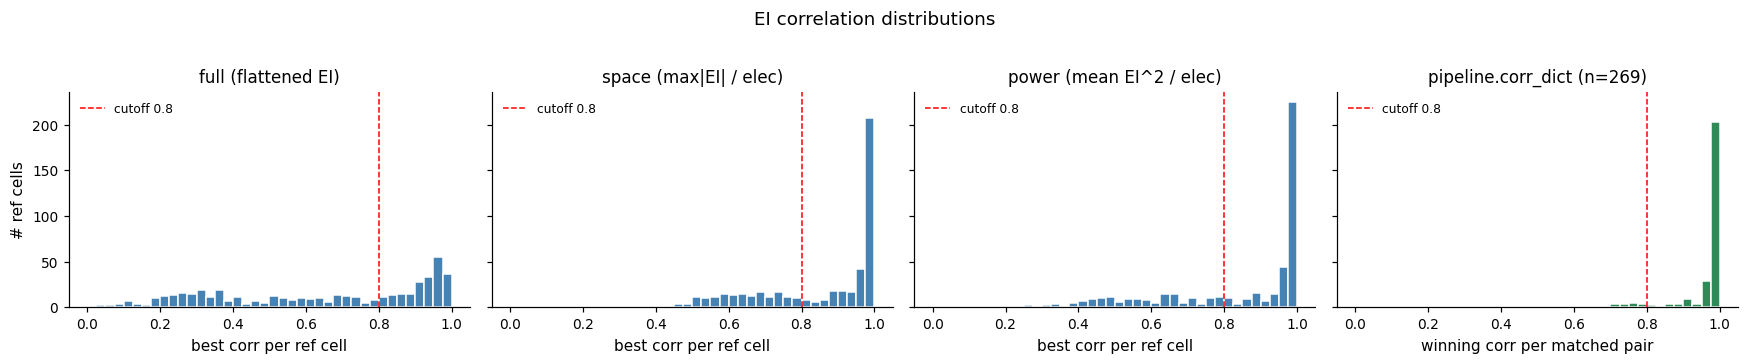

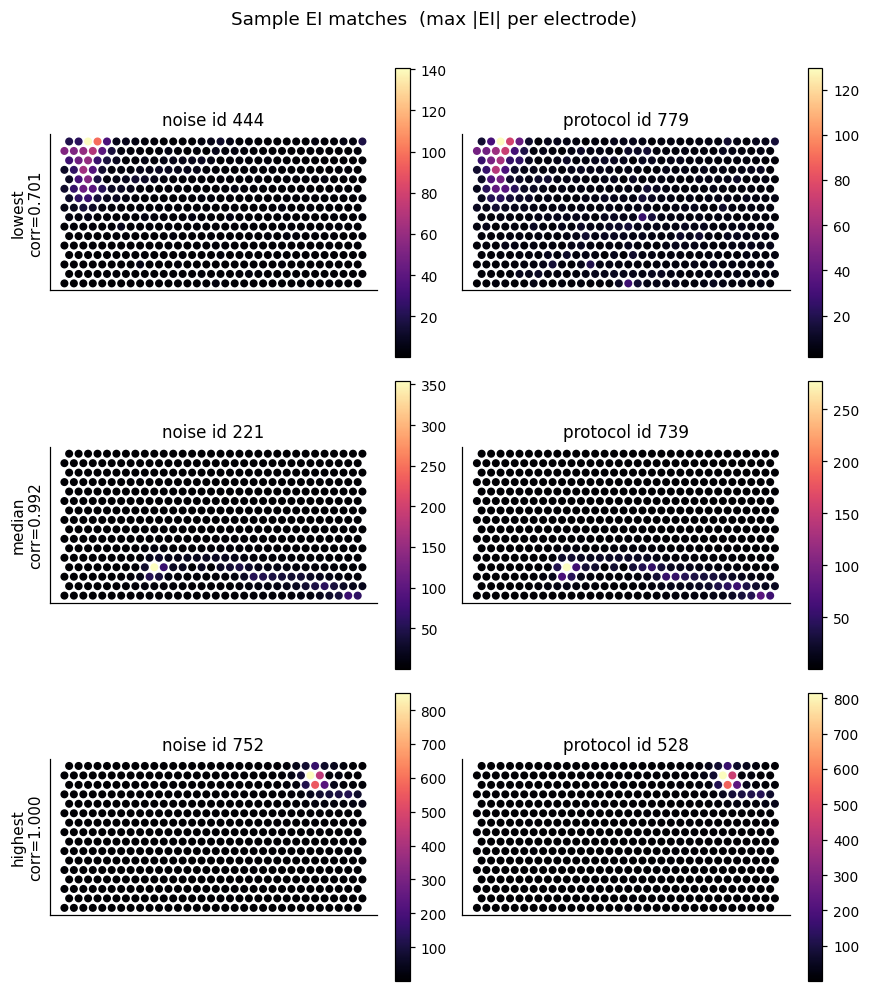

In [22]:
# --- EI-match diagnostics --------------------------------------------------
# Look at the three EI correlation metrics that cluster_match() uses, plus
# the cutoffs that gate a match, and a few sample matched pairs.
#
# cluster_match() (vision_utils.py) compares each noise cell to every
# protocol cell using three flavours of EI correlation:
#   * 'full'  - flattened (n_elec * n_samples) waveform vector
#   * 'space' - max(|EI|) per electrode  (spatial footprint)
#   * 'power' - mean(EI^2) per electrode (electrode power)
# A pair is kept only if it passes ALL of these gates:
#   1. best 'full/space/power' corr > corr_cutoff (=0.8)
#   2. next-best corr < 0.9 * best, in both directions (uniqueness)
#   3. reverse best-match points back at the same reference cell

from retinanalysis.utils.vision_utils import ei_corr

CORR_CUTOFF = 0.8
UNIQUENESS  = 0.9

# Recompute the three correlation matrices: shape (n_noise, n_protocol).
M_full  = ei_corr(analysis_chunk, response_block, method='full',  n_removed_channels=1)
M_space = ei_corr(analysis_chunk, response_block, method='space', n_removed_channels=1)
M_power = ei_corr(analysis_chunk, response_block, method='power', n_removed_channels=1)

# Best-match correlation per noise cell (one row per ref cell).
best_full  = np.nanmax(M_full,  axis=1)
best_space = np.nanmax(M_space, axis=1)
best_power = np.nanmax(M_power, axis=1)

# Winning correlation actually retained by cluster_match per matched pair.
matched_corr = np.array(list(pipeline.corr_dict.values()))

# ---- Thresholds + counts -------------------------------------------------
n_ref  = len(analysis_chunk.cell_ids)
n_test = len(response_block.cell_ids)
n_match = len(pipeline.corr_dict)
print('EI-match thresholds (hard-coded in vision_utils.cluster_match):')
print(f'  corr_cutoff       = {CORR_CUTOFF}   (max EI correlation must exceed this)')
print(f'  uniqueness ratio  = {UNIQUENESS}   (next-best < {UNIQUENESS} * best, both directions)')
print(f'  reverse-best test : reverse best-match must point back to the ref cell')
print()
print(f'noise (ref) cells      : {n_ref}')
print(f'protocol (test) cells  : {n_test}')
print(f'matched pairs          : {n_match}  ({100*n_match/max(n_ref,1):.1f}% of ref cells)')
if n_match:
    print(f'matched corr           : median {np.median(matched_corr):.3f}, '
          f'min {matched_corr.min():.3f}, max {matched_corr.max():.3f}')
    print(f'best-full   > cutoff   : {(best_full  > CORR_CUTOFF).sum()} / {n_ref}')
    print(f'best-space  > cutoff   : {(best_space > CORR_CUTOFF).sum()} / {n_ref}')
    print(f'best-power  > cutoff   : {(best_power > CORR_CUTOFF).sum()} / {n_ref}')

# ---- Histograms ----------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, vals, name in zip(
    axes[:3],
    [best_full, best_space, best_power],
    ['full (flattened EI)', 'space (max|EI| / elec)', 'power (mean EI^2 / elec)'],
):
    ax.hist(vals, bins=40, range=(0, 1), color='steelblue', edgecolor='white')
    ax.axvline(CORR_CUTOFF, color='red', ls='--', lw=1.0, label=f'cutoff {CORR_CUTOFF}')
    ax.set_xlabel('best corr per ref cell')
    ax.set_title(name)
    ax.legend(loc='upper left', fontsize=8)
axes[0].set_ylabel('# ref cells')
axes[3].hist(matched_corr, bins=40, range=(0, 1), color='seagreen', edgecolor='white')
axes[3].axvline(CORR_CUTOFF, color='red', ls='--', lw=1.0, label=f'cutoff {CORR_CUTOFF}')
axes[3].set_xlabel('winning corr per matched pair')
axes[3].set_title(f'pipeline.corr_dict (n={n_match})')
axes[3].legend(loc='upper left', fontsize=8)
fig.suptitle('EI correlation distributions', y=1.02)
fig.tight_layout()
plt.show()

# ---- Sample matched pairs (low / median / high corr) ---------------------
if n_match >= 3:
    electrode_xy = analysis_chunk.vcd.get_electrode_map()
    # corr_dict is noise_id -> corr; protocol id comes from match_dict.
    sorted_items = sorted(pipeline.corr_dict.items(), key=lambda kv: kv[1])
    picks = [(sorted_items[0],                       'lowest'),
             (sorted_items[len(sorted_items)//2],    'median'),
             (sorted_items[-1],                      'highest')]

    fig, axes = plt.subplots(len(picks), 2, figsize=(8, 3.0*len(picks)))
    for row, ((noise_id, c), tag) in enumerate(picks):
        proto_id = pipeline.match_dict[noise_id]
        for col, (obj, cell_id, src) in enumerate([
            (analysis_chunk, noise_id, 'noise'),
            (response_block, proto_id, 'protocol'),
        ]):
            ei = obj.d_EIs[cell_id]
            footprint = np.max(np.abs(ei), axis=1)
            ax = axes[row, col]
            sc = ax.scatter(electrode_xy[:, 0], electrode_xy[:, 1],
                            c=footprint, s=18, cmap='magma')
            ax.set_aspect('equal')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f'{src} id {cell_id}')
            plt.colorbar(sc, ax=ax, fraction=0.04)
        axes[row, 0].set_ylabel(f'{tag}\ncorr={c:.3f}', fontsize=10)
    fig.suptitle('Sample EI matches  (max |EI| per electrode)', y=1.0)
    fig.tight_layout()
    plt.show()
else:
    print('\nFewer than 3 matched pairs - skipping sample EI plots.')


## 4. Sanity-check the EI match

Plot the RFs the protocol cells inherited (via the match) next to the native RFs from the noise chunk. If matching is good, the two mosaics should look nearly identical per cell type.

Cell-type counts (after normalization):
cell_type
Unmatched    119
OnM          105
Unknown       85
OffM          46
OnP           36
Amacrine      12
OffS           6
OnS            2
Name: count, dtype: int64

Using cell_types: ['OnP', 'OnM', 'OffM', 'OffS']
Skipping (not present or <3 cells): ['OffP', 'SBC', 'A1', 'BT', 'OnS']


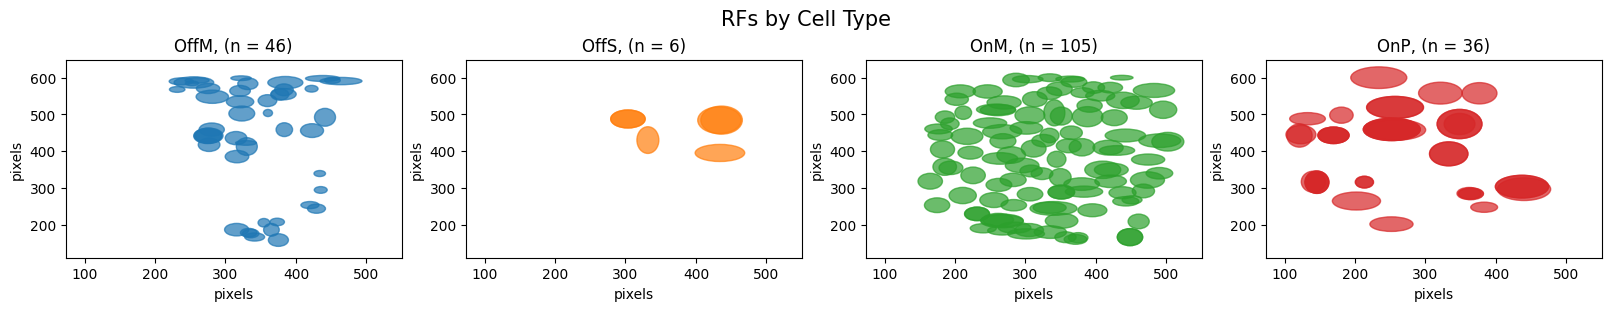

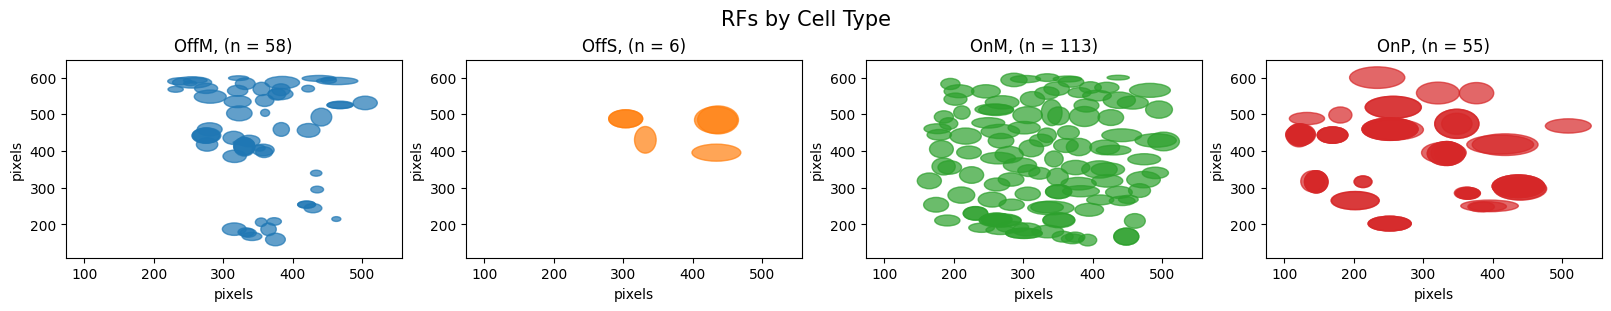

In [5]:
# Canonical types we'd like to look at (these mirror the labels in
# assets/cell_types.csv). The mapper is case-insensitive, so classification
# files using 'All/onP/', 'all/offp/', etc. will still resolve correctly.
requested_types = ['OnP', 'OffP', 'OnM', 'OffM', 'SBC', 'A1', 'BT', 'OnS', 'OffS']

# Re-map the existing cell_type column through the canonical list so any
# odd casing in the classification file collapses to the standard names.
def normalize(t):
    canon = ra.map_cell_type(t)        # case-insensitive lookup against cell_types.csv
    return canon if canon is not None else t

response_block.df_spike_times['cell_type'] = (
    response_block.df_spike_times['cell_type'].apply(normalize)
)

# Show what we ended up with
type_counts = response_block.df_spike_times['cell_type'].value_counts()
print('Cell-type counts (after normalization):')
print(type_counts.head(20))

# Keep only types that (a) are in our requested list and (b) actually exist
# with >=3 cells. Anything missing is silently skipped.
present_types = [t for t, n in type_counts.items() if n >= 3]
cell_types = ra.filter_available_types(requested_types, present_types)
skipped = [t for t in requested_types if t not in cell_types]
print(f'\nUsing cell_types: {cell_types}')
if skipped:
    print(f'Skipping (not present or <3 cells): {skipped}')

if len(cell_types) == 0:
    print('\nNo requested cell types found in this experiment — skipping RF plots.')
else:
    try:
        _ = pipeline.plot_rfs(cell_types=cell_types, minimum_n=3, b_zoom=True)
    except Exception as e:
        print(f'pipeline.plot_rfs skipped: {e}')
    try:
        _ = analysis_chunk.plot_rfs(
            cell_types=cell_types, minimum_n=3, b_zoom=True,
            typing_file=typing_file_name,
        )
    except Exception as e:
        print(f'analysis_chunk.plot_rfs skipped: {e}')

## 5. Inspect stimulus parameters

`stim_block.df_epochs` has one row per epoch with the params that varied (e.g. mean, variance, seed). `d_epoch_block_params` has the block-level params (preTime/stimTime/tailTime, etc.).

In [6]:
display(stim_block.df_epochs.head())

print('\nEpoch-block params:')
for k, v in stim_block.d_epoch_block_params.items():
    print(f'  {k}: {v}')

,epoch_index,currentBackgroundScale,backgroundIntensity,currentImageName,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,0.1,0.009608,00152,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 17.0, 34.0, 50.0, 67.0, 83.0, 100.0, 116...","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32377
1,1,10.0,0.960779,00152,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 115....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32378
2,2,0.1,0.035755,00459,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32379
3,3,10.0,3.575503,00459,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32380
4,4,0.1,0.020199,01151,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32381



Epoch-block params:
  D: 5.0
  amp: Amp1
  preTime: 30000.0
  stimTime: 30000.0
  tailTime: 0.0
  patchMean: all
  randomSeed: 1.0
  sampleRate: 1000.0
  onlineAnalysis: none
  backgroundScale: [0.1, 10.0]
  apertureDiameter: 0.0
  numberOfAverages: 30


## 6. Pull spike times across cells

`get_spike_xarr` returns an xarray with dims `(cell_id, epoch)`, each entry an array of spike times in ms. Coords include `cell_type`, so you can `.sel`/`.where` by type. Filtering by `cell_types` keeps only EI-matched, typed cells.

In [7]:
if len(cell_types) == 0:
    print('No usable cell types — skipping spike xarray.')
    spike_times = None
else:
    spike_times = ra.get_spike_xarr(response_block, cell_types=cell_types, minimum_n=3)
    spike_counts = xr.apply_ufunc(len, spike_times, vectorize=True)

    print(f'Spike xarray shape: {dict(spike_times.sizes)}')
    print(f'Cell types present: {sorted(np.unique(spike_times.cell_type.values))}')

    # Baseline (pre-stim) counts per cell x epoch
    pre_time = stim_block.d_epoch_block_params['preTime']

    def baseline_count(arr, pre_time):
        return int(np.sum(np.asarray(arr) < pre_time))

    baseline_counts = xr.apply_ufunc(
        baseline_count, spike_times,
        kwargs={'pre_time': pre_time}, vectorize=True,
    )

    display(spike_counts)

Spike xarray shape: {'cell_id': 193, 'epoch': 30}
Cell types present: [np.str_('OffM'), np.str_('OffS'), np.str_('OnM'), np.str_('OnP')]


<xarray.DataArray (cell_id: 193, epoch: 30)> Size: 46kB
array([[2555, 1786, 1513, ..., 1485, 1305, 1487],
       [ 272, 1361,  472, ...,  440,  597,  533],
       [2425, 1793, 1303, ...,  429,  990,  582],
       ...,
       [   0,    3,    3, ...,   14,    7,    2],
       [ 227,  213,  117, ...,   68,  143,  126],
       [  33,   47,    0, ...,    0,    0,    0]], shape=(193, 30))
Coordinates:
  * cell_id    (cell_id) int64 2kB 1 2 3 4 5 6 14 ... 570 571 575 588 599 600
    cell_type  (cell_id) <U4 3kB 'OnM' 'OnM' 'OnM' 'OnM' ... 'OffM' 'OnP' 'OnP'
    noise_id   (cell_id) int64 2kB 1 2 3 4 5 6 14 ... 570 571 575 588 599 600
  * epoch      (epoch) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29

## 7. Access STA + EI for a specific cell

After matching, you can look up any protocol cell's noise-chunk twin and grab its STA / EI / timecourse from `analysis_chunk`.

- `pipeline.match_dict[noise_cell_id] = protocol_cell_id` (noise → protocol)
- `analysis_chunk.d_EIs[noise_cell_id]` — electrical image
- `analysis_chunk.d_timecourses[noise_cell_id]` — RGB timecourses
- `analysis_chunk.d_ISIs[noise_cell_id]` — ISI distribution

Noise cell 1  <->  Protocol cell 1
EI shape: (512, 201)
Timecourse channels: ['red', 'green', 'blue']


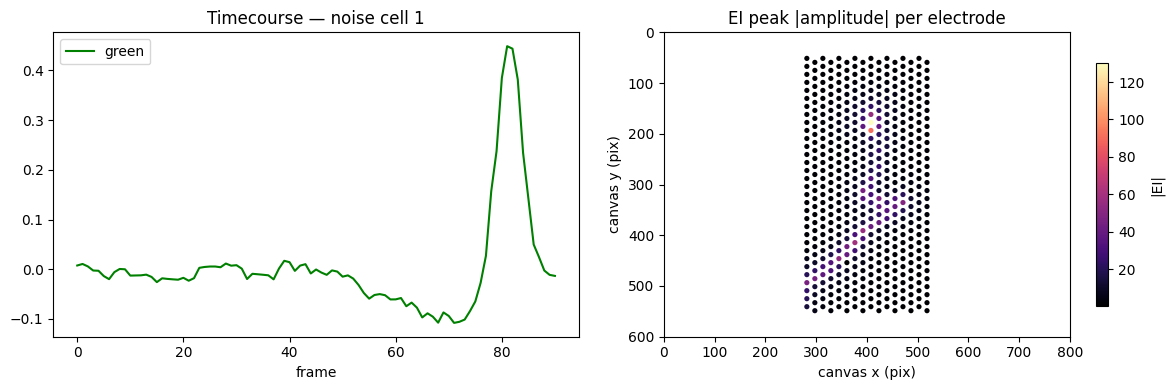

In [8]:
# Example: grab the first matched cell
noise_id, protocol_id = next(iter(pipeline.match_dict.items()))
print(f'Noise cell {noise_id}  <->  Protocol cell {protocol_id}')

ei = analysis_chunk.d_EIs[noise_id]
tc = analysis_chunk.d_timecourses[noise_id]

print(f'EI shape: {ei.shape}')
print(f'Timecourse channels: {list(tc.keys())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: spike-triggered timecourse(s).
axes[0].plot(tc['green'], color='g', label='green')
if not np.allclose(tc['red'], tc['green']):
    axes[0].plot(tc['red'], color='r', label='red')
    axes[0].plot(tc['blue'], color='b', label='blue')
axes[0].set_title(f'Timecourse — noise cell {noise_id}')
axes[0].set_xlabel('frame'); axes[0].legend()

# Right: per-electrode peak |EI| over time, plotted at the electrodes'
# canvas-pixel positions. The MEA-chip → canvas rotation is auto-resolved
# from the rig config (get_display_params_by_exp → mea_rotation_deg),
# so no rig-specific constants are needed in the notebook.
peak_abs = np.abs(ei).max(axis=-1)   # (n_electrodes,)
em_canvas = ra.electrode_positions_canvas_px(analysis_chunk)
canvas_w, canvas_h = analysis_chunk.canvas_size
sc = axes[1].scatter(em_canvas[:, 0], em_canvas[:, 1],
                     c=peak_abs, cmap='magma', s=14, edgecolors='none')
axes[1].set_xlim(0, canvas_w); axes[1].set_ylim(canvas_h, 0)
axes[1].set_aspect('equal')
axes[1].set_title(f'EI peak |amplitude| per electrode')
axes[1].set_xlabel('canvas x (pix)'); axes[1].set_ylabel('canvas y (pix)')
fig.colorbar(sc, ax=axes[1], shrink=0.8, label='|EI|')
plt.tight_layout()

## 8. Regenerate the stimulus (optional)

`ra.regen_stimulus(stim_block)` dispatches by protocol name to a per-protocol regen
function (registered in `retinanalysis.regen`). It returns an `xarray.Dataset` with
per-epoch trajectories + metadata, plus base images attached as
`ds.attrs['base_images']` when the protocol's source repo is findable under
`ra.PROTOCOL_REPOS_ROOT`.

If the repo isn't cloned locally, regen still returns trajectories/metadata and
just prints a heads-up — the rest of the notebook keeps working.

PROTOCOL_REPOS_ROOT: /Users/chrischen/Documents/GitHub
Registered regen protocols: ['edu.washington.riekelab.chris.protocols.MEAVariableMeanNoiseCone', 'edu.washington.riekelab.chris.protocols.VariableMeanSpatialNoise', 'edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']

regen_stimulus: using retinanalysis.regen.eye_movement_alt_bg.regen for edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground
[regen] found repo: /Users/chrischen/Documents/GitHub/turner-package
[regen] loaded 5 base image(s) from /Users/chrischen/Documents/GitHub/turner-package/resources/VHsubsample_20160105 (missing: none)

<xarray.Dataset> Size: 880kB
Dimensions:                 (epoch: 30, time: 1800)
Coordinates:
  * epoch                   (epoch) int64 240B 0 1 2 3 4 5 ... 24 25 26 27 28 29
    time_s                  (time) float64 14kB 0.0 0.01667 ... 29.97 29.98
Dimensions without coordinates: time
Data variables:
    xTraj_um                (e

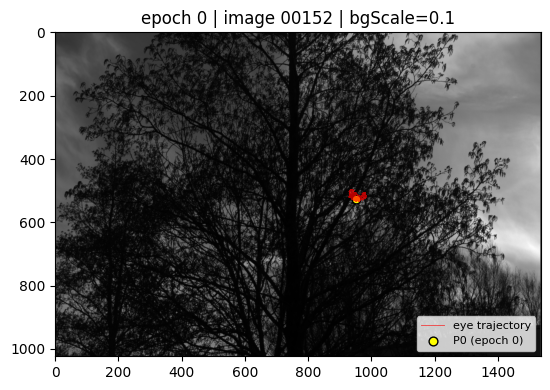

In [9]:
print(f'PROTOCOL_REPOS_ROOT: {ra.PROTOCOL_REPOS_ROOT or "(unset)"}')
print(f'Registered regen protocols: {ra.available_protocols()}\n')

stim_ds = ra.regen_stimulus(stim_block)

if stim_ds is None:
    print('\nNo regen function for this protocol — skipping.')
else:
    print()
    print(stim_ds)
    base_images = stim_ds.attrs.get('base_images', {})
    print(f'\nbase images available: {sorted(base_images.keys()) or "(none)"}')

    if base_images:
        # Show the first epoch's image with the saved P0 marked and the
        # eye-movement trajectory overlaid (in VH pixels, in image coords).
        e = 0
        img_name = str(stim_ds.image_name.values[e])
        img = base_images[img_name]
        p0x = float(stim_ds.currentP0_x_vhpix.values[e])
        p0y = float(stim_ds.currentP0_y_vhpix.values[e])

        um_per_vhpix = stim_ds.attrs['vh_um_per_pixel']
        traj_x_vhpix = stim_ds.xTraj_um.values[e] / um_per_vhpix
        traj_y_vhpix = stim_ds.yTraj_um.values[e] / um_per_vhpix

        fig, ax = plt.subplots(1, 1, figsize=(7, 4))
        ax.imshow(img, cmap='gray', origin='upper')
        ax.plot(p0x + traj_x_vhpix, p0y + traj_y_vhpix,
                color='red', lw=0.6, alpha=0.7, label='eye trajectory')
        ax.scatter([p0x], [p0y], color='yellow', s=40,
                   edgecolor='black', label=f'P0 (epoch {e})')
        ax.set_title(f'epoch {e} | image {img_name} | bgScale={stim_ds.currentBackgroundScale.values[e]:g}')
        ax.legend(loc='lower right', fontsize=8)
        plt.tight_layout()
        plt.show()

## 9. Render the displayed canvas + overlay mosaic and electrodes

`ra.render_displayed_canvas(stim_ds, epoch, frame=...)` returns a
`(canvas_h, canvas_w)` uint8 array — exactly what was on the monitor
that frame. Dispatches on `stim_ds.attrs['protocol_name']`:

- **`EyeMovementTrajectoryAlternatingBackground`**: VH image scaled by
  `vh_um_per_pixel / micronsPerPixel`, centered at canvas + `currentP0`
  offset, shifted by `xTraj_um`/`yTraj_um` at frame `k` (use `frame=None`
  for the pre-trajectory snapshot), background = `imageMean × bgScale`,
  clipped to `canvasSize`.
- **`VariableMeanSpatialNoise`**: stixel grid upscaled by `stixelSizePix`
  via `GL.NEAREST`, centered at canvas + per-frame jitter, background =
  `mean_sequence[frame]`, clipped to `canvasSize`.

The output drops straight into `plot_stim_with_mosaic(..., show_electrodes=True)`
with the default `frame_extent`. Electrodes are taken from
`vcd.get_electrode_map()` (MEA-chip µm) and converted via
`ra.electrode_positions_canvas_px(ac)`. The MEA-chip → canvas rotation
is resolved per rig from `get_display_params_by_exp(exp_name)`
(`mea_rotation_deg` key — Rig C = 90°, verified by minimum-distance
test on matched cells). Override per-call via `electrode_rotation_deg=`.

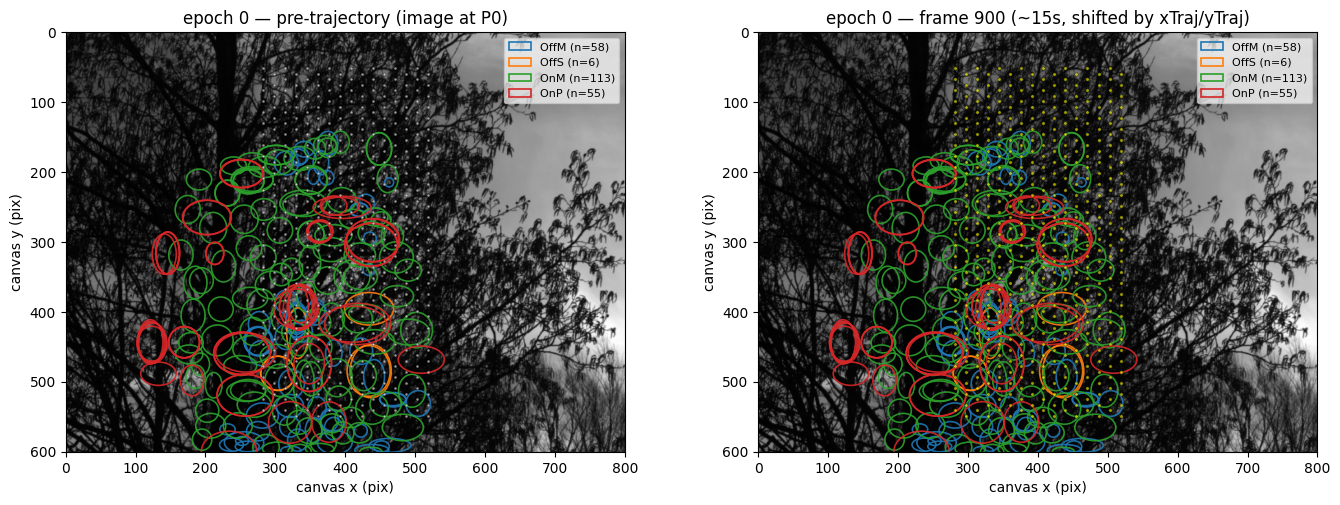

matched cells: n=232, nearest-electrode distance — median=7.8 px (30 µm), 90%ile=88.8 px


In [10]:
if stim_ds is not None and stim_ds.attrs.get('base_images'):
    # render_displayed_canvas → canvas-pixel buffer of exactly what the
    # monitor showed (image scaled by vh_um_per_pixel/microns_per_pixel,
    # offset by currentP0, shifted by eye trajectory at frame `k`,
    # background filled with backgroundIntensity, clipped to canvasSize).
    canvas_t0 = ra.render_displayed_canvas(stim_ds, epoch=0, frame=None)
    canvas_mid = ra.render_displayed_canvas(stim_ds, epoch=0, frame=900)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ra.plot_stim_with_mosaic(
        canvas_t0, analysis_chunk, cell_types=cell_types, minimum_n=3,
        ax=axes[0], show_electrodes=True,
        title='epoch 0 — pre-trajectory (image at P0)',
    )
    ra.plot_stim_with_mosaic(
        canvas_mid, analysis_chunk, cell_types=cell_types, minimum_n=3,
        ax=axes[1], show_electrodes=True,
        electrode_kwargs=dict(s=6, c='yellow', edgecolors='black', linewidths=0.4),
        title='epoch 0 — frame 900 (~15s, shifted by xTraj/yTraj)',
    )
    plt.tight_layout()
    plt.show()

    # Sanity check: matched cells should sit close to electrodes (each cell
    # is recorded by a nearby electrode). On a 30 µm hex array the typical
    # nearest-electrode distance is ~half the pitch (~15 µm).
    em_canvas = ra.electrode_positions_canvas_px(analysis_chunk)
    ppstix = analysis_chunk.pixels_per_stixel
    matched = (analysis_chunk.df_cell_params
               .query('typing_file_0 in @cell_types')['cell_id'].values)
    dists = []
    for cid in matched:
        rf = analysis_chunk.rf_params[cid]
        sta_xy = np.array([rf['center_x'] * ppstix, rf['center_y'] * ppstix])
        dists.append(np.linalg.norm(em_canvas - sta_xy, axis=1).min())
    dists = np.asarray(dists)
    print(f'matched cells: n={len(dists)}, '
          f'nearest-electrode distance — median={np.median(dists):.1f} px '
          f'({np.median(dists) * analysis_chunk.microns_per_pixel:.0f} µm), '
          f'90%ile={np.percentile(dists, 90):.1f} px')
else:
    print('No regen base images available — skipping displayed-canvas demo.')

## 10. Verify cell-type classification

The mosaic in section 4 is one check. Two more standard checks:

- **Mean temporal filter** — the green-channel STA timecourse averaged
  across cells of the same type should be tight and consistent
  (biphasic ON or OFF, peak at the same frame). Outliers drift apart.
- **Mean ISI distribution** — refractory period + post-spike timing.
  A coherent type has a tight refractory dip + similar bursting tail.

`ra.plot_cell_type_grid(analysis_chunk, cell_types, minimum_n=3)` stacks
all three panels per type into one figure.

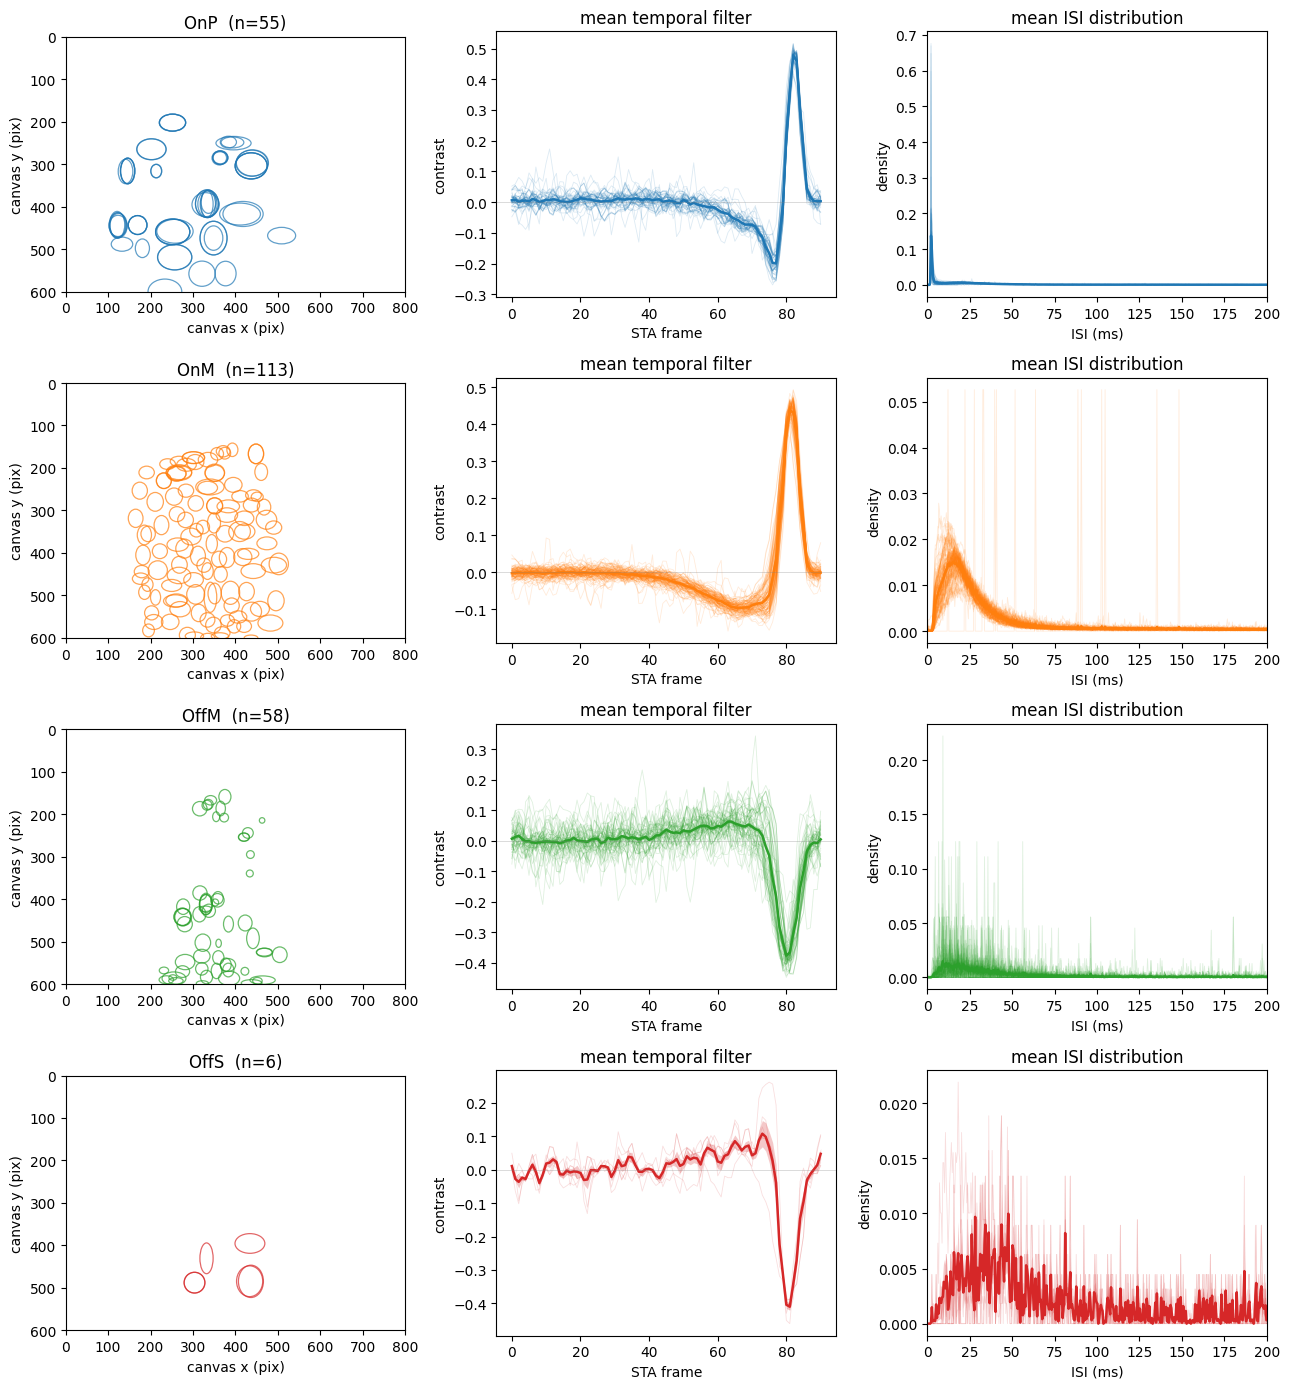

In [12]:
fig = ra.plot_cell_type_grid(analysis_chunk, cell_types, minimum_n=3)
plt.show()

## 11. Raster + PSTH for one cell type

Three things in one section:

1. **Population spike-rate histogram per cell type** — pool every `(cell, epoch)` count of one type into a single distribution. Type-typical cells cluster around the mode; outliers in the left tail are the same cells §14 will flag as failing the rate gate.
2. **Per-cell raster** — one row per `(cell, epoch)` pair (spikes as ticks).
3. **Population PSTH** — Gaussian-smoothed (10 ms σ), mean ± SEM across rows. Uses the same `spikeTimeToPSTH.m` convention as the patch workflow so patch + MEA results stay comparable.

Red dashed lines mark stim onset (`preTime`) and offset (`preTime + stimTime`).

In [ ]:
bp = stim_block.d_epoch_block_params
t_total_ms = bp['preTime'] + bp['stimTime'] + bp['tailTime']
epoch_s = t_total_ms / 1000.0

# 11a. Pool (cell, epoch) spike rates per type and plot one histogram per type.
# This is the cleanest visual check for "is this cell typical for its type?":
# outliers on the left tail are the same cells §14's rate gate will fail.
rate_threshold_hz = 1.0   # mirror §14's default min_rate_hz
df_st = response_block.df_spike_times
rates_by_type = {ct: [] for ct in cell_types}
for _, r in df_st.iterrows():
    ct = r['cell_type']
    if ct not in rates_by_type:
        continue
    for arr in r['spike_times']:
        arr = np.asarray(arr)
        n = int(((arr >= 0) & (arr <= t_total_ms)).sum()) if arr.size else 0
        rates_by_type[ct].append(n / epoch_s)

fig, hist_axes = plt.subplots(1, len(cell_types),
                              figsize=(4 * len(cell_types), 3.2),
                              sharey=True, squeeze=False)
hist_axes = hist_axes[0]
for i, ct in enumerate(cell_types):
    rates = np.asarray(rates_by_type[ct], dtype=float)
    ax = hist_axes[i]
    if rates.size:
        ax.hist(rates, bins=40, color=f'C{i}', alpha=0.85, edgecolor='none')
        ax.axvline(rate_threshold_hz, color='red', ls='--', lw=1.0,
                   label=f'{rate_threshold_hz:g} Hz threshold')
        ax.axvline(np.median(rates), color='black', ls=':', lw=1.0,
                   label=f'median {np.median(rates):.1f} Hz')
        ax.legend(loc='upper right', fontsize=8)
    ax.set_xlabel('rate (spikes/s)')
    ax.set_title(f'{ct}  (n={rates.size} cell-epochs)')
hist_axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

# 11b. Per-cell raster + population PSTH for the first 2 types (drop the
# [:2] slice to render all of them).
for ct in cell_types[:2]:
    fig, axes_rp = plt.subplots(2, 1, figsize=(11, 5),
                                 gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ra.plot_raster_with_psth(
        response_block, ct,
        t_end_ms=t_total_ms,
        pre_time_ms=bp['preTime'],
        stim_time_ms=bp['stimTime'],
        psth_sigma_ms=10.0,
        axes=axes_rp,
        raster_color=f'C{cell_types.index(ct)}',
    )
    plt.tight_layout()
    plt.show()

## 12. PSTH by condition

Protocol-specific analysis lives in
`retinanalysis.protocols.<protocol_module>` so each notebook stays lean.
For `EyeMovementTrajectoryAlternatingBackground` the natural split is
`currentBackgroundScale` (0.1 = dim background, 10 = bright background).

`analyze()` returns per-(cell-type × condition) PSTHs — one
`(n_cells, n_bins)` matrix each. `plot_psth_by_condition()` makes one
panel per type with conditions overlaid (mean ± SEM across cells).

In [ ]:
from retinanalysis.protocols import eye_movement_alt_bg as em

# Each image is shown twice (once per backgroundScale) — average across
# images would wash out per-image response structure, so we group by
# (image, backgroundScale) and plot one panel per image with bg overlaid.
results = em.analyze(
    pipeline,
    cell_types=cell_types,
    condition_keys=['currentImageName', 'currentBackgroundScale'],
    psth_sigma_ms=10.0,
    minimum_n=3,
)
print(f'condition_keys: {results["condition_keys"]}')
print(f'n_conditions: {len(results["conditions"])}  '
      f'(= n_images × n_bg_scales)')
print(f'types passing minimum_n: {results["cell_types"]}')

em.plot_psth_by_condition(results)  # auto-grids when len(keys) == 2
plt.show()

## 13. Per-experiment MEA→canvas calibration

The chip is physically remounted between recording days, so the geometry that maps electrode µm onto the display canvas is a *per-experiment* constant. We derive it empirically: for each cell, pair its AP-initiation EI electrode (a soma proxy) with its STA center on the canvas, then fit a 2D similarity transform (rotation + uniform scale + translation) by Procrustes/SVD. Robust trimming rejects outlier pairs (cells with bad STAs or off-array EIs).

Calibrations are stored at `<repo>/rig_calibrations/<exp_name>.json`. The overlay helper looks one up automatically — pass `recompute_alignment=True` to override with a fresh fit just for this chunk, or `save_recomputed=True` to also persist the new fit.

Convergence: residual is reported in µm. ~one electrode pitch (60 µm) on a well-fit chunk; bigger residuals point to noisy STA centers or many off-array EI peaks.

In [ ]:
from retinanalysis.utils import rig_calibration as rc

# 13a. Empirical array geometry (no hardcoded "60 µm pitch / 512 electrodes").
# Derived from analysis_chunk.vcd.get_electrode_map() so downstream filters
# scale with whichever array was actually used.
geom = ra.electrode_geometry(analysis_chunk)
print(f'electrode array: {geom["n_electrodes"]} channels, '
      f'pitch={geom["pitch_um"]:.1f} µm, '
      f'footprint {geom["width_um"]:.0f} x {geom["height_um"]:.0f} µm')

# 13b. Try to load an existing calibration for this experiment.
calib = rc.load_rig_calibration(analysis_chunk.exp_name)
if calib is None:
    print(f'No saved calibration for {analysis_chunk.exp_name}. Fitting fresh.')
    calib = rc.fit_calibration_for_chunk(analysis_chunk, verbose=True)
    path = rc.save_rig_calibration(calib)
    print(f'Saved → {path}')
else:
    print(f'Loaded calibration for {calib.exp_name} '
          f'(rig {calib.rig_id}, fit from {calib.n_recordings} recording(s))')

print(f'  rotation = {calib.rotation_deg:.2f}°')
print(f'  scale    = {calib.scale_px_per_um:.4f} px/µm   '
      f'(1/scale = {1.0/calib.scale_px_per_um:.3f} µm/px, rig-config = {analysis_chunk.microns_per_pixel:.3f})')
print(f'  trans    = ({calib.tx_px:.1f}, {calib.ty_px:.1f}) px   '
      f'(canvas center = {analysis_chunk.canvas_size[0]/2:.0f}, {analysis_chunk.canvas_size[1]/2:.0f})')
print(f'  residual = {calib.residual_um_rms:.1f} µm '
      f'({calib.residual_um_rms/geom["pitch_um"]:.2f} × pitch) '
      f'over {calib.n_cells} inlier cells')

# 13c. Visual comparison: overlay electrodes via the calibration vs the
# old centered-chip + rig-rotation geometry. Both panels zoom to the chip
# footprint and drop cells whose RFs are too far from any electrode — the
# default mosaic includes many noisy STAs whose centers land off-array,
# making the cell coverage *look* much larger than the recording area.
# Thresholds are in multiples of the empirical electrode pitch so the
# same call works across array types.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ra.plot_stim_with_mosaic(
    np.full((int(analysis_chunk.canvas_size[1]), int(analysis_chunk.canvas_size[0])), 0.85),
    analysis_chunk, cell_types=cell_types, minimum_n=3,
    ax=axes[0], show_electrodes=True,
    use_calibration=False,
    restrict_to_array_pitch=2.0,   # drop RFs > 2 electrode pitches off-array
    zoom_to_array=True,
    zoom_pad_pitch=2.0,
    title='electrode overlay: geometric (rig-config 90°)',
)
ra.plot_stim_with_mosaic(
    np.full((int(analysis_chunk.canvas_size[1]), int(analysis_chunk.canvas_size[0])), 0.85),
    analysis_chunk, cell_types=cell_types, minimum_n=3,
    ax=axes[1], show_electrodes=True,
    use_calibration=True,
    restrict_to_array_pitch=2.0,
    zoom_to_array=True,
    zoom_pad_pitch=2.0,
    title='electrode overlay: calibrated (EI↔STA fit)',
)
plt.tight_layout()
plt.show()

## 14. Per-cell QC inside the protocol

A cell can pass classification on the noise chunk and still misbehave inside a downstream protocol — drift off, drop out for runs of trials, or barely fire. `protocol_qc.block_qc_metrics` returns a per-cell metrics DataFrame; `filter_cells_by_qc` adds a boolean `passes` column with sensible defaults (override any threshold per-call).

Two automated gates do most of the work:

- **Adaptive firing rate.** Set `min_rate_hz` (default **1 Hz**); the per-epoch count threshold is `min_rate_hz × epoch_duration_s`. A cell passes the rate gate when at least `min_frac_epochs_above_rate` (default **80%**) of its epochs hit that threshold. Scales with epoch length so the same defaults work across 5 s, 30 s, and 60 s protocols.
- **Silent-epoch survival.** A cell passes when at least `min_frac_non_silent_epochs` (default **2/3**) of its epochs have ≥1 spike. Equivalent to "drop the silent epochs and keep the cell if at least two-thirds of its trials are still present" — without actually removing epochs (per-condition PSTH plumbing downstream stays intact).

Other reportable metrics (gateable by setting their thresholds): `mean_rate_hz`, `min_count_per_epoch`, `cv_count`, `fano` (off by default — scales with mean), `silent_trial_frac`, `silent_run_max` (consecutive zero-spike trials), `drift_score` (across-trial trend), `reliability_r` (split-half PSTH; off by default for mixed-condition protocols).

The QC outcome is persisted to `<OUTPUT_DIR>/<exp>/<protocol>/qc.csv` — the **initial good/bad tagging** for every cell. §16 (visual QC) and §17/§18 (archives) both honor it; the visual layer is purely additive.

In [23]:
from retinanalysis.utils.protocol_qc import (
    block_qc_metrics, filter_cells_by_qc, QCThresholds,
)

t_total_ms = (
    response_block.d_timing['pre_time_ms']
    + response_block.d_timing['stim_time_ms']
    + response_block.d_timing['tail_time_ms']
)

# Two adaptive gates — both are user-tunable here.
MIN_RATE_HZ = 1.0                  # firing-rate floor in spikes/s
MIN_FRAC_EPOCHS = 0.8              # fraction of epochs that must meet that rate
MIN_FRAC_NON_SILENT = 2.0 / 3.0    # cell kept iff ≥ this fraction of epochs has ≥1 spike

qc_metrics = block_qc_metrics(
    response_block, t_start_ms=0, t_end_ms=t_total_ms,
    min_rate_hz=MIN_RATE_HZ,
)
qc = filter_cells_by_qc(qc_metrics, thresholds=QCThresholds(
    min_rate_hz=MIN_RATE_HZ,
    min_frac_epochs_above_rate=MIN_FRAC_EPOCHS,
    min_frac_non_silent_epochs=MIN_FRAC_NON_SILENT,
))

epoch_s = qc['epoch_duration_s'].iloc[0]
print(f'epoch window: {epoch_s:.1f} s')
print(f'  rate gate:        ≥ {MIN_RATE_HZ:.1f} Hz × {epoch_s:.1f} s = '
      f'{MIN_RATE_HZ*epoch_s:.0f} spikes/epoch in ≥{100*MIN_FRAC_EPOCHS:.0f}% of epochs')
print(f'  silent-epoch gate: ≥ {100*MIN_FRAC_NON_SILENT:.0f}% of epochs have ≥1 spike')

n_pass = int(qc.passes.sum())
print(f'\nTotal cells: {len(qc)},  Passing QC: {n_pass} ({100*n_pass/len(qc):.1f}%)')
print('\nPass rate by cell type:')
for ct, sub in qc.groupby('cell_type'):
    rate = sub['mean_rate_hz'].median()
    print(f'  {ct:<12}  {sub.passes.sum():>4} / {len(sub):>4}  '
          f'({100*sub.passes.mean():3.0f}%)   median rate: {rate:5.1f} Hz')

# Persist this date's QC outcome — the initial good/bad tag set for every
# cell. §16 visual QC and §17/§18 archives all honor it downstream.
qc_path = ra.save_protocol_qc(qc, exp_name, protocol='eye_movement_alt_bg')
print(f'\nqc.csv → {qc_path}')

# Show the most informative failures: those that survive the rate gate
# but fail the silent-epoch gate (or vice versa) tell you which gate did
# the work for a given cell.
fails = qc[~qc.passes].sort_values('frac_non_silent_epochs')
print(f'\nFirst few failing cells ({len(fails)} total):')
display(fails[['cell_id', 'cell_type', 'n_epochs', 'mean_rate_hz',
               'frac_epochs_above_rate', 'frac_non_silent_epochs',
               'silent_run_max', 'drift_score']].head().round(2))

epoch window: 4.0 s
  rate gate:        ≥ 1.0 Hz × 4.0 s = 4 spikes/epoch in ≥80% of epochs
  silent-epoch gate: ≥ 67% of epochs have ≥1 spike

Total cells: 489,  Passing QC: 326 (66.7%)

Pass rate by cell type:
  Amacrine         5 /   20  ( 25%)   median rate:   1.5 Hz
  BlueMystery      5 /    6  ( 83%)   median rate:   5.2 Hz
  OffM            88 /   91  ( 97%)   median rate:  15.5 Hz
  OffMystery      11 /   18  ( 61%)   median rate:   2.8 Hz
  OffP            27 /   29  ( 93%)   median rate:  12.4 Hz
  OnM             45 /   68  ( 66%)   median rate:  15.5 Hz
  OnMystery        4 /    5  ( 80%)   median rate:   3.0 Hz
  OnP             12 /   14  ( 86%)   median rate:   5.2 Hz
  OnS              3 /    5  ( 60%)   median rate:   2.4 Hz
  Unknown          7 /   13  ( 54%)   median rate:   1.9 Hz
  Unmatched      119 /  220  ( 54%)   median rate:   3.9 Hz

qc.csv → /Volumes/ChrisProSSD/retinanalysis_output/20240523C/eye_movement_alt_bg/qc.csv

First few failing cells (163 total):


,cell_id,cell_type,n_epochs,mean_rate_hz,frac_epochs_above_rate,frac_non_silent_epochs,silent_run_max,drift_score
2,4,Unmatched,60,0.0,0.0,0.02,33,0.01
133,226,Unmatched,60,0.0,0.0,0.02,59,0.10
151,322,Unmatched,60,0.0,0.0,0.02,56,0.09
383,691,Unmatched,60,0.0,0.0,0.02,32,0.01
415,758,Unmatched,60,0.0,0.0,0.02,56,0.09


## 15. Per-cell PNG archive (mosaic + raster + PSTH)

Scrolling through every cell inline is painful past ~30 cells. `save_per_cell_plots` writes one `.png` per cell to a structured folder tree under `OUTPUT_DIR/cell_plots/<exp>/<chunk>/<protocol>/cells/<celltype>/cell_<id>.png`, plus a `mosaic_overview.png` and an `index.csv` summarizing what was rendered. Pass `qc_pass_only=qc` to skip cells that failed QC. Reruns are incremental — already-rendered PNGs are skipped unless you pass `overwrite=True`.

In [ ]:
from retinanalysis.utils.cell_plot_archive import save_per_cell_plots

# Save a small demo set (one per main type) so this cell runs fast in the
# notebook. Drop `cell_ids=` to render the full main-type archive.
demo_ids = []
for ct in ['OnP', 'OffP', 'OnM', 'OffM']:
    sub = qc[(qc.cell_type == ct) & qc.passes].head(1)
    demo_ids.extend(sub.cell_id.astype(int).tolist())
print(f'Rendering {len(demo_ids)} demo cells: {demo_ids}')

# Passing stim_block enables condition-coloring: raster rows + PSTH lines
# are split by `currentBackgroundScale` (auto-detected for this protocol).
# Already-rendered cells are skipped — re-running this cell is incremental.
index = save_per_cell_plots(
    analysis_chunk,
    response_block,
    stim_block=stim_block,
    cell_ids=demo_ids,
    qc_pass_only=qc,
    ndf=float(stim_block.df_epochs['epoch_parameters'].iloc[0].get('NDF', float('nan'))),
    overwrite=False,
    verbose=True,
)
display(index)

## 16. Visual QC (optional) — click through each cell, tag good/bad

**This step is optional.** §14 wrote an automated QC pass/fail to `qc.csv`. Use the visual-QC GUI when you want to **further restrict** the archive by eyeballing each cell.

The workflow is intentionally iterative:

1. First time through, skip this section (no PNGs exist yet) and run §17 / §18 to build the initial archive.
2. Come back here once PNGs are on disk — `ra.browse_cells_qc(exp_name)` opens a widget that pages through cells (raster left, PSTH right) with `Good` / `Bad` / `Prev` / `Next` buttons. Each click writes a row to `<OUTPUT_DIR>/<exp>/<protocol>/visual_qc.csv`; the session is resumable.
3. Re-run §17 / §18. They auto-detect `visual_qc.csv` and restrict the per-cell archive to cells tagged `good`. `cell_match.csv` is left comprehensive so downstream EI-stats joins still see the full population.

Downstream selection in population analyses (no change):

```python
cells = ra.select_good_cells()   # uses visual_qc.csv if present, else QC-pass set
```

Requirements: `ipywidgets` (already in the `retinanalysis` kernel).

In [25]:
# Launch the per-cell GUI for the date picked in §2. If no PNGs exist
# yet, the widget prints a message and returns — run §17 (single date) or
# §18 (batch) first to build the archive, then come back here to tag.
ra.browse_cells_qc(exp_name)

## 17. Archive the picked date (single date)

§15 above only renders a handful of demo cells. To write the **full** per-cell PNG archive for the date selected in §2 — `mosaic.png`, `index.csv`, `cell_match.csv`, and `cells/<celltype>/cell_<id>_{raster,psth}.png` — call `ra.analyze_experiment(exp_name, datafile_name)`. This is the same driver §18 uses internally per date in its batch loop; running it here builds the archive for *just* the one date you've been inspecting, before committing to the full batch.

**Visual-QC integration is automatic.** If `visual_qc.csv` exists for this experiment (from §16), the call below restricts the archive to **cells labeled `good`** — no extra flags needed. Otherwise it falls back to every cell that passed §14's automated QC (first-pass default). `cell_match.csv` is left comprehensive either way; visual QC is a downstream filter, not data loss.

In [ ]:
# Full archive for the date picked in §2. analyze_experiment now reads
# visual_qc.csv on its own (respect_visual_qc=True by default) and
# restricts the per-cell PNG step to cells tagged 'good' when the file
# exists — no extra notebook glue needed. overwrite=True regenerates
# every targeted PNG.

# ---- USER INPUT --------------------------------------------------------
# Subdirectory under <OUTPUT_DIR>/<exp_name>/. Default uses the protocol
# short name (e.g. 'eye_movement_alt_bg') — fine when the date has one
# datafile of this protocol. When multiple datafiles of the SAME protocol
# exist on this date, set protocol_subdir below (or set
# append_datafile_to_subdir=True) to disambiguate, otherwise each run
# overwrites the previous one.
protocol_subdir = None             # e.g. 'eye_movement_alt_bg_data032', or None
append_datafile_to_subdir = False  # True → auto-append datafile_name
# ------------------------------------------------------------------------

result = ra.analyze_experiment(
    exp_name,
    datafile_name=datafile_name,
    overwrite=True,
    fit_calibration=False,
    n_jobs=-1,
    verbose=True,
    protocol_subdir=protocol_subdir,
    append_datafile_to_subdir=append_datafile_to_subdir,
)
print(f'\nDone: {result["exp_name"]} / {result["datafile_name"]} — '
      f'QC-pass pool: {result["n_cells_passed_qc"]}/{result["n_cells_total"]}')
print(f'  output_dir: {result["output_dir"]}')


## 18. Run the archive for one or many dates (standalone)

This section is **self-contained** — run cell 1 (imports), then jump straight here. `ra.analyze_experiments` packages every step the earlier cells did manually into a single call per date: ss_version + typing file + datafile auto-detect, pipeline build, optional rig calibration, type normalization, QC, composite `mosaic.png` (with temporal-filter + ISI rows), and per-cell `cell_<id>_raster.png` + `cell_<id>_psth.png`.

**Visual-QC integration:** for any date that already has a `visual_qc.csv` in its archive folder, the batch driver restricts that date's PNG step to cells tagged `good` (same logic as §17). Pass `respect_visual_qc=False` to override.

Runs are parallel (`n_jobs=-1` uses every CPU core). Use `on_error='log'` so a bad date is recorded in the summary instead of aborting the batch.

In [ ]:
# Section 18 is SELF-CONTAINED — you only need cell 1 (imports) to run it.
# It will query the protocol registry on its own and dispatch the archive
# pipeline over every experiment found, in parallel.

import os
import pandas as pd

# ---- USER INPUT --------------------------------------------------------
# Yes/no: should we (re)save figures for every cell?
#   True  → render and OVERWRITE all PNGs (use this to refresh stale plots).
#           Per-date visual_qc.csv (if present) restricts the per-cell
#           PNG step to cells tagged 'good'.
#   False → skip the archive step entirely (just list the batch and stop).
SAVE_FIGURES = True
# ------------------------------------------------------------------------

PROTOCOL_SEARCH = 'AlternatingBackground'   # substring matched against protocol names

# Build the date list from the protocol registry, keeping only experiments
# whose sort output is present on disk.
_exp_search = ra.get_datasets_from_protocol_names(PROTOCOL_SEARCH)
_available = set(os.listdir(ra.ANALYSIS_DIR))
_exp_search = _exp_search[_exp_search['exp_name'].isin(_available)]
batch_dates = _exp_search['exp_name'].unique().tolist()

# Subset variants — uncomment / adapt as needed:
# batch_dates = ['20220823C', '20221123C', '20230502C']                                            # hand-pick
# batch_dates = _exp_search.query("exp_name >= '20230101C'")['exp_name'].unique().tolist()        # by date
# batch_dates = _exp_search.query('NDF == 2.0')['exp_name'].unique().tolist()                     # by NDF

print(f'Batch run over {len(batch_dates)} dates: {batch_dates}')
print(f'SAVE_FIGURES = {SAVE_FIGURES}  '
      f'({"overwrite all PNGs" if SAVE_FIGURES else "skip archive step"})')

if not SAVE_FIGURES:
    print('SAVE_FIGURES is False — not calling ra.analyze_experiments. '
          'Set SAVE_FIGURES = True above to (re)render PNGs.')
else:
    results = ra.analyze_experiments(
        batch_dates,
        protocol_search=PROTOCOL_SEARCH,    # resolves datafile per date
        fit_calibration=False,              # True on first pass to seed calibrations
        overwrite=True,                     # resave every PNG (driven by SAVE_FIGURES)
        n_jobs=-1,                          # all CPU cores for per-cell rendering
        on_error='log',                     # keep going past per-date failures
        respect_visual_qc=True,             # restrict to good-tagged cells when present
        verbose=True,
    )

    summary = pd.DataFrame([
        {k: r.get(k) for k in
         ['exp_name', 'datafile_name', 'chunk_name',
          'n_cells_total', 'n_cells_passed_qc', 'ndf', 'error']}
        for r in results
    ])
    display(summary)


## 19. Cell-match table & EI stats (persisted across sessions)

`analyze_experiment` (§17 / §18) writes one `cell_match.csv` per experiment alongside `index.csv`. Each row links a noise-chunk cell to its protocol-side match and snapshots the EI summary stats so future sessions can pull this without rebuilding the pipeline:

| column | meaning |
|---|---|
| `protocol_cell_id` ↔ `noise_cell_id` | the EI-based match (was only in `pipeline.match_dict` before) |
| `ei_corr` | best EI correlation that won the match |
| `ei_peak_amp` | max \|EI\| across electrodes/samples |
| `ei_peak_electrode`, `ei_peak_x_um`, `ei_peak_y_um` | soma electrode + chip-µm location |
| `ei_peak_sample` | sample idx of the peak (spike-timing offset within the EI window) |
| `ei_n_active_electrodes` | electrodes whose peak \|EI\| ≥ 20% of the global peak (footprint size) |
| `ei_spread_um` | RMS distance of active electrodes from the peak — footprint width |
| `ei_snr` | peak / median(inactive-electrode peaks) — coarse SNR |

Load with `ra.load_cell_match()`. For population analyses, join to `ra.select_good_cells()` on `(exp_name, protocol_cell_id ↔ cell_id)` to attach EI stats to the QC-passed pool.

In [ ]:
cm = ra.load_cell_match()
print(f'cell_match: {len(cm)} cells from {cm["exp_name"].nunique()} experiments\n')

# Per-(experiment, type) summary medians — quick way to spot bad chunks.
agg = (cm.groupby(['exp_name', 'cell_type'])
         [['ei_corr', 'ei_peak_amp', 'ei_n_active_electrodes',
           'ei_spread_um', 'ei_snr']]
         .median()
         .round(2))
display(agg)

# Distributions across all cells of the main types.
import matplotlib.pyplot as plt
main_types = [t for t in ['OnP', 'OffP', 'OnM', 'OffM']
              if t in cm['cell_type'].unique()]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ct in main_types:
    sub = cm[cm.cell_type == ct]
    axes[0].hist(sub['ei_corr'],   bins=40, histtype='step', label=ct)
    axes[1].hist(sub['ei_snr'],    bins=40, histtype='step', label=ct,
                 range=(0, 500))
    axes[2].hist(sub['ei_spread_um'], bins=40, histtype='step', label=ct)
axes[0].set_xlabel('EI correlation'); axes[0].set_title('match quality')
axes[1].set_xlabel('EI SNR');         axes[1].set_title('signal strength')
axes[2].set_xlabel('EI spread (µm)'); axes[2].set_title('footprint size')
for ax in axes:
    ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

# Population-ready join: QC-passed cells annotated with their EI stats.
cells = ra.select_good_cells().rename(columns={'cell_id': 'protocol_cell_id'})
pop = cells.merge(cm, on=['exp_name', 'protocol_cell_id', 'cell_type'],
                   how='left', suffixes=('', '_cm'))
print(f'\npopulation pool: {len(pop)} cells '
      f"(matched to EI stats: {pop['ei_corr'].notna().sum()})")
display(pop.head())

## 20. Offline data store (build once, reload fast)

After §16/§17 leaves a curated visual-QC set per experiment, `ra.load_or_build_offline` packages everything an analysis needs — metadata, condition table, per-cell spike times, smoothed PSTHs, STA fit, EI summary — into a single HDF5 at `{OUTPUT_DIR}/{exp}/{protocol}/offline.h5`. Subsequent sessions just **load** the file and never touch DataJoint or the SSD pipeline.

- **First call**: builds the pipeline, runs QC, intersects with `visual_qc.csv` (good cells only), writes `offline.h5`. ~1–2 min/date.
- **Re-runs**: reload is ~0.2 s. Pass `overwrite=True` to rebuild.

The returned `OfflineDataset` exposes:

| attribute / method | what it is |
|---|---|
| `ds.meta`, `ds.timing` | scalars (experiment id, datafile, ndf, preTime/stimTime/sample_rate) |
| `ds.epochs` | DataFrame, one row per epoch + condition columns |
| `ds.cells` | DataFrame, one row per saved cell (cell_type, STA fit, EI stats) |
| `ds.spike_times(cell_id)` | list of arrays (ms), one per epoch |
| `ds.psth_matrix(cell_id)` | `(n_epochs, n_bins)` Hz (Gaussian-smoothed) |
| `ds.psth_time_ms()` | shared bin-center time axis |


In [ ]:
# §20 — Build / load the offline store for one experiment.
# First call: 1–2 min; subsequent calls: <1 s.

EXP = '20221123C'
PROTOCOL = 'eye_movement_alt_bg'

ds = ra.load_or_build_offline(
    EXP, protocol=PROTOCOL,
    protocol_search='AlternatingBackground',
    overwrite=False, verbose=True,
)
print(ds)
print('cell types:', ds.cell_types())
display(ds.epochs.head())
display(ds.cells.head())


## 21. Offline analyses — PSTH avg, spike distance, movie repeat, population metrics

Each analysis takes the `OfflineDataset` and returns a DataFrame (or dict for population metrics). Results are saved next to `offline.h5` as CSV so cross-date aggregation is just `pd.concat`.

- **`analyze_offline`** — per-(cell-type × condition) mean PSTHs (offline equivalent of §15's `eye_movement_alt_bg.analyze`).
- **`spike_distance_analysis`** — Victor-Purpura distance (port of `spkd_with_scr.m`) over a 5-s window per trial. Reports within-condition mean (variability inside a condition) and across-condition mean; **`d_diff = d_across - d_within_avg > 0`** means the condition modulates the response.
- **`movie_repeat_analysis`** — split `stimTime` into cycle-1 vs cycle-2 (15 s + 15 s), drop first second of each, compare per cell × condition: correlation, RMSE, mean-rate ratio (adaptation index), and optional per-trial VP distance.
- **`population_time_scale_metrics`** — time-resolved population vector divergence (Cohen's d, Euclidean / cosine distance, cumulative |Δrate|, per-bin Mann-Whitney AUC) comparing the two `currentBackgroundScale` levels per cell type.

Run `run_protocol_analyses` to compute + save VP + movie-repeat CSVs in one call.


In [ ]:
# §21a — Average PSTH by (cell type × condition). Offline = no DJ needed.
from retinanalysis.protocols import eye_movement_alt_bg as ema

r = ema.analyze_offline(ds, minimum_n=3)
print(f'cell types: {r["cell_types"]}')
print(f'{len(r["conditions"])} conditions, {len(r["time_ms"])} time bins')

ema.plot_psth_by_condition(r, show_individual_cells=False)


In [ ]:
# §21b — Movie-repeat comparison: cycle 1 vs cycle 2 (15s each, drop first 1s).
# compute_vp=False keeps it fast (~30 s); enable for per-trial VP timing differences.
mr = ema.movie_repeat_analysis(
    ds, cycle_sec=15.0, drop_first_sec=1.0,
    cell_types=['OnP', 'OffP', 'OnM', 'OffM'],
    compute_vp=False,
)
print(f'rows: {len(mr)}')
display(mr.groupby('cell_type')[['n_trials',
                                  'rate_cycle1_hz', 'rate_cycle2_hz',
                                  'rate_ratio',
                                  'corr_cycle12', 'rmse_cycle12_hz']]
          .median().round(3))

# Save to disk for cross-date pooling
ema.save_movie_repeat(mr, ds.exp_name)


In [ ]:
# §21c — Population time-scale metrics: two backgroundScale levels per cell type.
# Returns dict {cell_type: {cohens_d_mean, pop_euclid_dist, pop_cosine_dist, ...}}.
import matplotlib.pyplot as plt

pm = ema.population_time_scale_metrics(
    ds, primary_key='currentBackgroundScale',
    cell_types=['OnP', 'OffP', 'OnM', 'OffM'],
    smooth_ms=100.0, minimum_n=3,
)
t_ms = pm['time_ms']
pre = ds.timing['preTime_ms']; stim = ds.timing['stimTime_ms']

types = pm['cell_types']
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ct in types:
    d = pm[ct]
    axes[0].plot(t_ms, d['cohens_d_abs_mean'], label=f'{ct} (n={d["n_cells"]})')
    axes[1].plot(t_ms, d['pop_euclid_dist'], label=ct)
    axes[2].plot(t_ms, d['cum_abs_divergence'], label=ct)
for ax in axes:
    ax.axvline(pre, color='r', lw=0.5, ls='--', alpha=0.5)
    ax.axvline(pre+stim, color='r', lw=0.5, ls='--', alpha=0.5)
axes[0].set_ylabel('mean |Cohen\'s d|')
axes[1].set_ylabel('pop Euclid dist')
axes[2].set_ylabel('cum |Δrate|·dt (spikes·cells)')
axes[2].set_xlabel('time (ms)')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle(f'{ds.exp_name}: low vs high background scale, time-resolved')
fig.tight_layout()


In [ ]:
# §21d — Spike-distance (Victor-Purpura) across backgroundScale, within image.
# Default pair_within=('currentImageName',): for each image, pair trials across
# the low vs high backgroundScale.  C-accelerated DP makes this fast — under 5s
# for ~170 cells × 5 images.
sd = ema.spike_distance_analysis(
    ds, window_sec=5.0, cost_per_sec=4.0,
    cell_types=['OnP', 'OffP', 'OnM', 'OffM'],
    pair_within=('currentImageName',),   # hold image constant, compare BG scale
    n_trials_cap=None,                    # use every trial — fast in C
)
print(f'rows: {len(sd)}; cells: {sd["cell_id"].nunique()}; '
      f'images: {sd["group_key"].nunique()}')

display(sd.groupby('cell_type')[['d_within_avg', 'd_across', 'd_diff']]
          .agg(['median', 'count']).round(2))

ema.save_spike_distance(sd, ds.exp_name)


## 22. Cross-date aggregation

Once every experiment has been through §20–§21 (each writes `offline.h5`, `spike_distance.csv`, `movie_repeat.csv` to its own folder), pooling across dates is just a `concat`.

- `ra.load_offline_many()` — dict `{exp_name: OfflineDataset}` for every experiment with `offline.h5` on disk.
- `ema.aggregate_psth_across_dates(offlines)` — pool per-cell mean PSTHs into one (n_cells_total, n_bins) matrix per (cell_type, condition); pass to `ema.plot_psth_by_condition`.
- `ema.load_spike_distance_many()` / `ema.load_movie_repeat_many()` — concatenated long-format DataFrames with `exp_name` tags.


In [ ]:
# §22 — Cross-date pooled analyses.
offlines = ra.load_offline_many()  # all dates with offline.h5
print(f'experiments loaded: {len(offlines)}')
for exp, ds_ in offlines.items():
    print(f'  {exp}: {len(ds_.cell_ids)} cells, types={ds_.cell_types()}')

# Pool PSTHs across dates
pooled = ema.aggregate_psth_across_dates(offlines, minimum_n=5)
print(f'\npooled types: {pooled["cell_types"]} from {pooled["n_dates"]} dates')
ema.plot_psth_by_condition(pooled, show_individual_cells=False)

# Pool spike-distance & movie-repeat CSVs
sd_all = ema.load_spike_distance_many()
mr_all = ema.load_movie_repeat_many()
print(f'\nspike_distance rows: {len(sd_all)} from '
      f'{sd_all["exp_name"].nunique() if not sd_all.empty else 0} dates')
print(f'movie_repeat rows: {len(mr_all)} from '
      f'{mr_all["exp_name"].nunique() if not mr_all.empty else 0} dates')

# Headline cross-date summaries
if not sd_all.empty:
    display(sd_all.groupby(['cell_type'])
                  [['d_within_avg', 'd_across', 'd_diff']]
                  .agg(['median', 'count']).round(2))
if not mr_all.empty:
    display(mr_all.groupby(['cell_type'])
                  [['rate_ratio', 'corr_cycle12', 'rmse_cycle12_hz']]
                  .agg(['median', 'count']).round(3))
